# FINESST synthetic hierarchical-population demonstration

This notebook creates the proposal's explanatory hierarchical Bayesian modeling (HBM) figure. Every planet, posterior sample, population parameter, and recovered trend is **synthetic**. The figure is not a preliminary population result and contains no real planet names or observed spectra.

## Methodological provenance

The statistical motivation follows the hierarchical atmospheric-retrieval framework of Lustig-Yaeger et al. (2022, *AJ*, 163, 140; DOI: `10.3847/1538-3881/ac5034`). That paper demonstrates a CO$_2$--instellation experiment for simulated rocky planets. No values are digitized from it here. This notebook instead constructs the requested synthetic gas-planet atmospheric mass--metallicity example and explicitly propagates each planet's full retrieval posterior through posterior-sample reweighting.

In [1]:
#***** Imports and portable path setup *****#
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
from IPython.display import display


def locate_run_directory():
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if candidate.name == 'run' and (candidate / 'FINESST').is_dir():
            return candidate
        if candidate.name == 'FINESST' and (candidate.parent / 'data').is_dir():
            return candidate.parent
        if (candidate / 'run' / 'FINESST').is_dir():
            return candidate / 'run'
    raise FileNotFoundError('Could not locate POSEIDON/run.')


RUN_DIRECTORY = locate_run_directory()
FINESST_DIRECTORY = RUN_DIRECTORY / 'FINESST'
if str(FINESST_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(FINESST_DIRECTORY))

from FINESST_HBM_Population_Demonstration import (
    default_config,
    generate_synthetic_population,
    infer_hierarchical_population,
    make_figure,
    save_products,
)

config = default_config(RUN_DIRECTORY)
SCRIPT_PATH = FINESST_DIRECTORY / 'FINESST_HBM_Population_Demonstration.py'
print('Using run directory:', RUN_DIRECTORY)

Using run directory: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run


## Synthetic population configuration

All choices that define the synthetic population and individual retrieval posteriors are centralized below. `RETRIEVAL_PRIOR_RANGE` is a broad uniform prior in $\log_{10}(Z_{\rm atm}/Z_\star)$. The stored prior density is therefore constant inside this interval and is retained explicitly for hierarchical reweighting.

In [2]:
#***** ALL synthetic-population inputs *****#
RANDOM_SEED = 270107
N_PLANETS = 30
MASS_RANGE_MJ = (0.03, 10.0)
TRUE_INTERCEPT = 0.68
TRUE_SLOPE = -0.62
TRUE_INTRINSIC_SCATTER = 0.22
RETRIEVAL_PRIOR_RANGE = (-1.0, 2.5)

POSTERIOR_SAMPLES_PER_PLANET = 3000
INFERENCE_SAMPLES_PER_PLANET = 600

# Information levels sum to N_PLANETS.
N_TIGHT = 8
N_MODERATE = 11
N_WEAK = 9
N_UPPER_LIMIT = 2
TIGHT_SIGMA_RANGE_DEX = (0.09, 0.16)
MODERATE_SIGMA_RANGE_DEX = (0.20, 0.34)
WEAK_SIGMA_RANGE_DEX = (0.42, 0.68)

# Fractions apply to non-upper-limit cases.
SKEWED_POSTERIOR_FRACTION = 0.22
MIXTURE_POSTERIOR_FRACTION = 0.22
UPPER_LIMIT_OFFSET_RANGE_DEX = (0.22, 0.42)
UPPER_LIMIT_TRANSITION_WIDTH_DEX = 0.08

config.synthetic.random_seed = RANDOM_SEED
config.synthetic.n_planets = N_PLANETS
config.synthetic.mass_range_mj = MASS_RANGE_MJ
config.synthetic.true_intercept = TRUE_INTERCEPT
config.synthetic.true_slope = TRUE_SLOPE
config.synthetic.true_intrinsic_scatter = TRUE_INTRINSIC_SCATTER
config.synthetic.retrieval_prior_range = RETRIEVAL_PRIOR_RANGE
config.synthetic.posterior_samples_per_planet = POSTERIOR_SAMPLES_PER_PLANET
config.synthetic.inference_samples_per_planet = INFERENCE_SAMPLES_PER_PLANET
config.synthetic.n_tight = N_TIGHT
config.synthetic.n_moderate = N_MODERATE
config.synthetic.n_weak = N_WEAK
config.synthetic.n_upper_limit = N_UPPER_LIMIT
config.synthetic.tight_sigma_range = TIGHT_SIGMA_RANGE_DEX
config.synthetic.moderate_sigma_range = MODERATE_SIGMA_RANGE_DEX
config.synthetic.weak_sigma_range = WEAK_SIGMA_RANGE_DEX
config.synthetic.skewed_fraction = SKEWED_POSTERIOR_FRACTION
config.synthetic.mixture_fraction = MIXTURE_POSTERIOR_FRACTION
config.synthetic.upper_limit_offset_range = UPPER_LIMIT_OFFSET_RANGE_DEX
config.synthetic.upper_limit_transition_width = UPPER_LIMIT_TRANSITION_WIDTH_DEX

## Hierarchical inference configuration

The likelihood is evaluated exactly as a posterior-sample average,

\[
\log \mathcal{L}_{\rm pop}=\sum_i\log\left[\frac{1}{N_i}\sum_j
\frac{\mathcal{N}(y_{ij}\mid\alpha+\beta x_i,\sigma_{\rm int})}
{\pi_i(y_{ij})}\right],
\]

using `scipy.special.logsumexp`. Uniform finite hyperpriors are used over the grid ranges below. The flat null model fixes $\beta=0$ and re-infers $\alpha$ and $\sigma_{\rm int}$.

In [3]:
#***** Hierarchical grid and sampling controls *****#
ALPHA_GRID_RANGE = (-0.20, 1.55)
BETA_GRID_RANGE = (-1.45, 0.35)
SIGMA_INTRINSIC_GRID_RANGE = (0.05, 0.65)
N_ALPHA_GRID = 31
N_BETA_GRID = 37
N_SIGMA_GRID = 25
GRID_EVALUATION_CHUNK_SIZE = 256
N_HYPERPARAMETER_SAMPLES = 30000
RELATION_GRID_SIZE = 300
RUN_GRID_CONVERGENCE_CHECK = True
COARSE_GRID_STRIDE = 2

config.grid.alpha_range = ALPHA_GRID_RANGE
config.grid.beta_range = BETA_GRID_RANGE
config.grid.sigma_range = SIGMA_INTRINSIC_GRID_RANGE
config.grid.n_alpha = N_ALPHA_GRID
config.grid.n_beta = N_BETA_GRID
config.grid.n_sigma = N_SIGMA_GRID
config.grid.evaluation_chunk_size = GRID_EVALUATION_CHUNK_SIZE
config.grid.n_hyperparameter_samples = N_HYPERPARAMETER_SAMPLES
config.grid.relation_grid_size = RELATION_GRID_SIZE
config.grid.run_grid_convergence_check = RUN_GRID_CONVERGENCE_CHECK
config.grid.coarse_grid_stride = COARSE_GRID_STRIDE

## Overall figure size, margins, and spacing

In [4]:
#***** Figure geometry *****#
FIGURE_WIDTH_INCHES = 7.5
FIGURE_HEIGHT_INCHES = 4.7
PANEL_WIDTH_RATIOS = (1.0, 1.0)
HORIZONTAL_PANEL_SPACE = 0.19
FIGURE_LEFT_MARGIN = 0.085
FIGURE_RIGHT_MARGIN = 0.985
FIGURE_BOTTOM_MARGIN = 0.14
FIGURE_TOP_MARGIN = 0.955

config.layout.figure_width_inches = FIGURE_WIDTH_INCHES
config.layout.figure_height_inches = FIGURE_HEIGHT_INCHES
config.layout.width_ratios = PANEL_WIDTH_RATIOS
config.layout.horizontal_space = HORIZONTAL_PANEL_SPACE
config.layout.left_margin = FIGURE_LEFT_MARGIN
config.layout.right_margin = FIGURE_RIGHT_MARGIN
config.layout.bottom_margin = FIGURE_BOTTOM_MARGIN
config.layout.top_margin = FIGURE_TOP_MARGIN

## POSEIDON-style typography, axes, and palette

In [5]:
#***** Typography, ticks, line widths, and color-blind-safe palette *****#
USE_SANS_SERIF = False
SERIF_FONT = 'DejaVu Serif'
SANS_SERIF_FONT = 'DejaVu Sans'
AXIS_LABEL_FONTSIZE = 12.5
TICK_LABEL_FONTSIZE = 10.5
LEGEND_FONTSIZE = 8.5
ANNOTATION_FONTSIZE = 8.5
PANEL_LABEL_FONTSIZE = 13.0
AXIS_BOX_LINEWIDTH = 0.8
MAJOR_TICK_LENGTH = 4.0
MINOR_TICK_LENGTH = 2.2
MAIN_LINEWIDTH = 1.7

POSTERIOR_COLOR = '#0072B2'
RECOVERED_RELATION_COLOR = '#D55E00'
SYNTHETIC_TRUTH_COLOR = '#009E73'
NULL_RELATION_COLOR = '#4D4D4D'
UPPER_LIMIT_COLOR = '#6A3D9A'

config.style.use_sans_serif = USE_SANS_SERIF
config.style.serif_font = SERIF_FONT
config.style.sans_serif_font = SANS_SERIF_FONT
config.style.axis_label_size = AXIS_LABEL_FONTSIZE
config.style.tick_label_size = TICK_LABEL_FONTSIZE
config.style.legend_size = LEGEND_FONTSIZE
config.style.annotation_size = ANNOTATION_FONTSIZE
config.style.panel_label_size = PANEL_LABEL_FONTSIZE
config.style.axes_line_width = AXIS_BOX_LINEWIDTH
config.style.tick_length = MAJOR_TICK_LENGTH
config.style.minor_tick_length = MINOR_TICK_LENGTH
config.style.line_width = MAIN_LINEWIDTH
config.style.posterior_color = POSTERIOR_COLOR
config.style.recovered_color = RECOVERED_RELATION_COLOR
config.style.truth_color = SYNTHETIC_TRUTH_COLOR
config.style.null_color = NULL_RELATION_COLOR
config.style.upper_limit_color = UPPER_LIMIT_COLOR

## Panel and slope-inset controls

In [6]:
#***** Shared panel axes and synthetic label *****#
X_AXIS_LABEL = r'$\log_{10}(M_p/M_J)$'
Y_AXIS_LABEL = r'$\log_{10}(Z_{\rm atm}/Z_\star)$'
X_AXIS_LIMITS = None  # None derives limits from MASS_RANGE_MJ.
Y_AXIS_LIMITS = (-1.02, 2.52)
SHOW_MINOR_TICKS = True
SYNTHETIC_LABEL = 'Synthetic demonstration'
SHOW_SYNTHETIC_LABEL_IN_EACH_PANEL = False
SYNTHETIC_LABEL_FIGURE_POSITION = (0.50, 0.985)

#***** Panel (a): full individual posteriors *****#
SHOW_SYNTHETIC_TRUTH_POINTS = True
VIOLIN_GRID_SIZE = 220
VIOLIN_WIDTH_FRACTION = 0.34
VIOLIN_KDE_BANDWIDTH = 0.22
VIOLIN_DENSITY_FLOOR_FRACTION = 0.012
VIOLIN_OPACITY_BY_INFORMATION_CLASS = {
    'tight': 0.58,
    'moderate': 0.46,
    'weak': 0.30,
    'upper_limit': 0.25,
}
UPPER_LIMIT_HATCH = '///'
POSTERIOR_MEDIAN_MARKER_SIZE = 2.8
SYNTHETIC_TRUTH_MARKER_SIZE = 2.5
PANEL_A_LEGEND_KWARGS = {
    'loc': 'lower left',
    'frameon': False,
    'ncol': 1,
    'handlelength': 1.8,
    'handletextpad': 0.5,
}

#***** Panel (b): recovered relation and null comparison *****#
SHOW_SYNTHETIC_TRUTH_RELATION = True
MEAN_RELATION_BAND_OPACITY = 0.30
PREDICTIVE_BAND_OPACITY = 0.13
BACKGROUND_POSTERIOR_INTERVAL_OPACITY = 0.23
PANEL_B_LEGEND_KWARGS = {
    'loc': 'lower left',
    'bbox_to_anchor': (0.01, 0.01),
    'frameon': False,
    'ncol': 1,
    'handlelength': 1.9,
    'handletextpad': 0.5,
}
HYPERPARAMETER_ANNOTATION_POSITION = (0.60, 0.045)
HYPERPARAMETER_ANNOTATION_FONTSIZE = 8.5

#***** Slope-posterior inset *****#
SLOPE_INSET_BOUNDS = (0.52, 0.55, 0.44, 0.37)
SLOPE_INSET_X_LABEL = r'Population slope, $\beta$'
SLOPE_INSET_TICK_LABEL_FONTSIZE = 7.5
SLOPE_INSET_AXIS_LABEL_FONTSIZE = 8.0
SLOPE_INSET_INTERVAL_OPACITY = 0.30
NO_MASS_DEPENDENCE_LABEL = 'No mass\ndependence'
NO_MASS_DEPENDENCE_TEXT_POSITION = (0.0, 0.94)
NO_MASS_DEPENDENCE_FONTSIZE = 6.8

config.panels.x_label = X_AXIS_LABEL
config.panels.y_label = Y_AXIS_LABEL
config.panels.x_limits = X_AXIS_LIMITS
config.panels.y_limits = Y_AXIS_LIMITS
config.panels.show_minor_ticks = SHOW_MINOR_TICKS
config.panels.synthetic_label = SYNTHETIC_LABEL
config.panels.show_synthetic_label_each_panel = SHOW_SYNTHETIC_LABEL_IN_EACH_PANEL
config.panels.synthetic_label_figure_xy = SYNTHETIC_LABEL_FIGURE_POSITION
config.panels.show_synthetic_truth_points = SHOW_SYNTHETIC_TRUTH_POINTS
config.panels.violin_grid_size = VIOLIN_GRID_SIZE
config.panels.violin_width_fraction = VIOLIN_WIDTH_FRACTION
config.panels.violin_bandwidth = VIOLIN_KDE_BANDWIDTH
config.panels.violin_density_floor_fraction = VIOLIN_DENSITY_FLOOR_FRACTION
config.panels.violin_alpha_by_class = VIOLIN_OPACITY_BY_INFORMATION_CLASS
config.panels.upper_limit_hatch = UPPER_LIMIT_HATCH
config.panels.posterior_median_marker_size = POSTERIOR_MEDIAN_MARKER_SIZE
config.panels.truth_marker_size = SYNTHETIC_TRUTH_MARKER_SIZE
config.panels.panel_a_legend_kwargs = PANEL_A_LEGEND_KWARGS
config.panels.show_synthetic_truth_relation = SHOW_SYNTHETIC_TRUTH_RELATION
config.panels.mean_band_alpha = MEAN_RELATION_BAND_OPACITY
config.panels.predictive_band_alpha = PREDICTIVE_BAND_OPACITY
config.panels.background_interval_alpha = BACKGROUND_POSTERIOR_INTERVAL_OPACITY
config.panels.panel_b_legend_kwargs = PANEL_B_LEGEND_KWARGS
config.panels.hyperparameter_annotation_axes_xy = HYPERPARAMETER_ANNOTATION_POSITION
config.panels.hyperparameter_annotation_fontsize = HYPERPARAMETER_ANNOTATION_FONTSIZE
config.panels.inset_bounds = SLOPE_INSET_BOUNDS
config.panels.inset_x_label = SLOPE_INSET_X_LABEL
config.panels.inset_tick_label_size = SLOPE_INSET_TICK_LABEL_FONTSIZE
config.panels.inset_axis_label_size = SLOPE_INSET_AXIS_LABEL_FONTSIZE
config.panels.inset_interval_alpha = SLOPE_INSET_INTERVAL_OPACITY
config.panels.no_mass_dependence_label = NO_MASS_DEPENDENCE_LABEL
config.panels.no_mass_dependence_text_xy = NO_MASS_DEPENDENCE_TEXT_POSITION
config.panels.no_mass_dependence_fontsize = NO_MASS_DEPENDENCE_FONTSIZE

## Generate individual posteriors and run the HBM

The deterministic sample subset used for grid integration is selected evenly from each stored posterior. All 3000 samples per planet remain saved for plotting, diagnostics, and reuse.

In [7]:
#***** Generate the reproducible synthetic population *****#
population = generate_synthetic_population(config)
print('Generated planets:', population.names.size)
print('Posterior sample array shape:', population.posterior_samples.shape)
print('Information classes:', {
    name: int((population.information_class == name).sum())
    for name in ('tight', 'moderate', 'weak', 'upper_limit')
})

#***** Infer the full and flat-null population models *****#
result = infer_hierarchical_population(population, config)
fig, axes = make_figure(population, result, config)
plt.close(fig)


Generated planets: 30
Posterior sample array shape: (30, 3000)
Information classes: {'tight': 8, 'moderate': 11, 'weak': 9, 'upper_limit': 2}


## Recovery and numerical diagnostics

In [8]:
#***** Verify recovery, grid stability, and sample-reweighting support *****#
def print_interval(name, values, truth=None):
    low, median, high = values
    message = f'{name}: {median:.3f} (+{high-median:.3f}/-{median-low:.3f})'
    if truth is not None:
        message += f' | synthetic truth = {truth:.3f}'
    print(message)


print_interval('alpha', result.quantiles['alpha'], TRUE_INTERCEPT)
print_interval('beta', result.quantiles['beta'], TRUE_SLOPE)
print_interval(
    'sigma_int', result.quantiles['sigma_intrinsic'], TRUE_INTRINSIC_SCATTER
)
print(f'log Bayes factor (sloped vs flat): {result.log_bayes_factor_full_vs_null:.3f}')
print('Validation:', result.validation)
print('Grid convergence:', result.convergence)

recovery_flags = [
    result.validation['alpha_truth_inside_68pct'],
    result.validation['beta_truth_inside_68pct'],
    result.validation['sigma_truth_inside_68pct'],
]
if not all(recovery_flags):
    warnings.warn(
        'At least one synthetic truth lies outside its recovered 68% interval. '
        'Inspect the configured random realization and grid before using the figure.'
    )

alpha: 0.671 (+0.071/-0.070) | synthetic truth = 0.680
beta: -0.620 (+0.093/-0.093) | synthetic truth = -0.620
sigma_int: 0.254 (+0.059/-0.047) | synthetic truth = 0.220
log Bayes factor (sloped vs flat): 11.720
Validation: {'alpha_truth_inside_68pct': True, 'beta_truth_inside_68pct': True, 'sigma_truth_inside_68pct': True, 'minimum_importance_ess': 602.8427042471949, 'median_importance_ess': 2254.133854333269, 'upper_limit_cases_retained': 2}
Grid convergence: {'performed': True, 'coarse_grid_stride': 2, 'fine_weighted_quantiles': {'alpha': [0.6166666666666667, 0.675, 0.7333333333333334], 'beta': [-0.7000000000000001, -0.6, -0.55], 'sigma_intrinsic': [0.2, 0.25, 0.32499999999999996]}, 'coarse_weighted_quantiles': {'alpha': [0.6166666666666667, 0.6166666666666667, 0.7333333333333334], 'beta': [-0.75, -0.65, -0.55], 'sigma_intrinsic': [0.2, 0.25, 0.3]}, 'median_absolute_differences': {'alpha': 0.05833333333333335, 'beta': 0.050000000000000044, 'sigma_intrinsic': 0.0}}


## Save data products and publication figure

population_csv: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/data/FINESST_26/Figure_3/synthetic_planet_population.csv
posterior_samples: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/data/FINESST_26/Figure_3/synthetic_individual_posteriors.npz
hierarchical_products: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/data/FINESST_26/Figure_3/hierarchical_posterior_products.npz
metadata: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/data/FINESST_26/Figure_3/synthetic_truth_and_recovery.json
pdf: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/POSEIDON_output/WASP-107b/plots/FINESST/figure3_HBM_population_demo.pdf
png: /home/eraul/wisconsin/work/atmosphere_research_2026/POSEIDON/run/POSEIDON_output/WASP-107b/plots/FINESST/figure3_HBM_population_demo.png


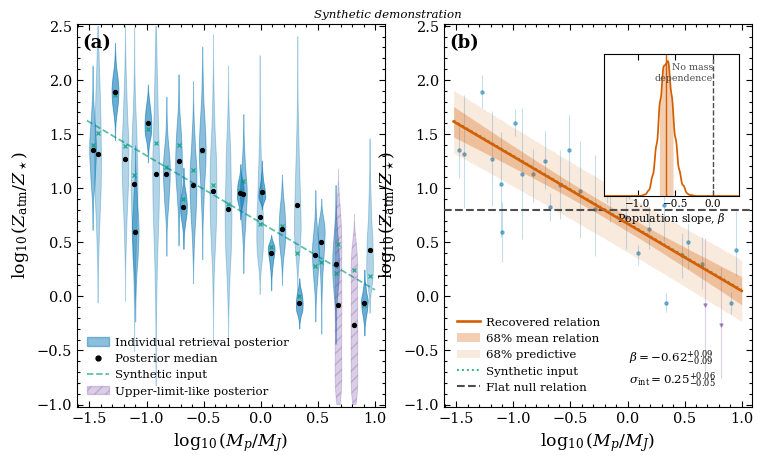

In [9]:
#***** Save reproducible data, metadata, vector PDF, and 300 dpi PNG *****#
output_paths = save_products(
    population,
    result,
    fig,
    config,
    script_path=SCRIPT_PATH,
)
for label, path in output_paths.items():
    print(f'{label}: {path}')

display(fig)

## Interpretation guardrail

Panel **(a)** shows why replacing each retrieval with a symmetric error bar or posterior median discards information: constrained, skewed, multimodal, weak, and upper-limit-like posteriors all enter differently. Panel **(b)** shows how the planned HBM jointly infers normalization, slope, and intrinsic scatter while retaining those full posteriors and explicitly evaluating a flat null relation. The recovered trend is a controlled simulation check, not evidence for an observed exoplanet population trend.